In [25]:
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import scipy.signal as signal

In [26]:
# define path to data and sampling frequency
# adjust the path depending on if you run this script locally or on Kaggle
# DATA_PATH = '/kaggle/input/competitions/ppg-br-exercise-1/mhealth26_ex1.npy'  # for Kaggle
DATA_PATH = './mhealth26_ex1.npy'  # when running locally
FS = 100

In [27]:
# load dictionary from .npy
data = np.load(DATA_PATH, allow_pickle=True).item()

# extract arrays
X_train = data['train_ppg']      
y_train = data['train_labels']   
X_test  = data['test_ppg']       

In [28]:
# example function to plot any signal with time on the x-axis
def plot_signal(signal, title, ylabel, sampling_rate=100):
    x = np.linspace(0, len(signal) / sampling_rate, len(signal))
    t = pd.to_datetime(x, unit='s')

    fig, ax = plt.subplots()
    ax.plot(t, signal)
    ax.set_title(title)
    ax.set_xlabel('Time [min:sec]')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%M:%S'))
    plt.show()

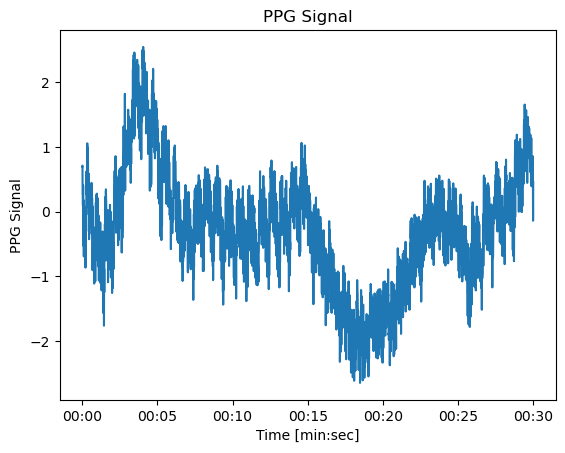

In [29]:
# plot the first 30 seconds of the unfiltered ppg signal of the first window
plot_signal(X_test[19][0:30*FS], 'PPG Signal', 'PPG Signal')

# Pre-Training

## PREPROCESSING

In [30]:
# PREPROCESSING
# Replace direct high-pass filtering with polynomial baseline subtraction.
# This keeps the pulse morphology but removes slow drift more gently.

from scipy import signal
import numpy as np

def lowpass_filter(ppg_window, fs=100, cutoff_hz=10.0, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_hz / nyquist
    sos = signal.butter(order, normal_cutoff, btype='lowpass', output='sos')
    return signal.sosfiltfilt(sos, ppg_window)

def preprocess_window(ppg_window, fs=100, hp_cutoff_hz=0.04, lp_cutoff_hz=10.0, poly_degree=3):
    # keep hp_cutoff_hz in the signature so the rest of the notebook does not break
    # even though we are no longer using a direct high-pass filter

    t = np.linspace(-1, 1, len(ppg_window))
    coeffs = np.polyfit(t, ppg_window, poly_degree)
    baseline = np.polyval(coeffs, t)

    x = ppg_window - baseline
    x = lowpass_filter(x, fs=fs, cutoff_hz=lp_cutoff_hz, order=4)
    return x

## EXTRACT RESPIRATORY SIGNALS

In [32]:
# RESAMPLE RESPIRATORY SIGNALS

from scipy.interpolate import CubicSpline

RESP_FS = 4  # higher than nyquist frequency (2 x 0.6 Hz)


def resample_resp(ppg_window, extract_fn, fs=100, resp_fs=RESP_FS):
    
    # find peaks and troughs (use maximum heart rate of ~150 bpm)
    peaks, _ = signal.find_peaks(ppg_window, distance=int(0.4 * fs), prominence=0)
    troughs, _ = signal.find_peaks(-ppg_window, distance=int(0.4 * fs))

    beat_times = []
    beat_values = []

    if extract_fn == 'bw':
        for pk in peaks:\

            # pair up peaks and troughs
            preceding = troughs[troughs < pk]
            if len(preceding) == 0:
                continue
            tr = preceding[-1]

            # append to list
            beat_times.append(pk / fs)
            beat_values.append((ppg_window[pk] + ppg_window[tr]) / 2.0)

    elif extract_fn == 'am':
        for pk in peaks:

            # pair up peaks and troughs
            preceding = troughs[troughs < pk]
            if len(preceding) == 0:
                continue
            tr = preceding[-1]

            # append to list
            beat_times.append(pk / fs)
            beat_values.append(ppg_window[pk] - ppg_window[tr])

    elif extract_fn == 'fm':

        # check if there are at least 3 peaks, otherwise peak detection failed
        if len(peaks) < 3:
            duration = len(ppg_window) / fs
            n_out = int(duration * resp_fs)
            return np.zeros(n_out), np.linspace(0, duration, n_out, endpoint=False)

        # calculate inter-beat interval
        ibi = np.diff(peaks).astype(float) / fs

        # append to list
        beat_times = (peaks[1:] / fs).tolist()
        beat_values = ibi.tolist()

    beat_times = np.array(beat_times)
    beat_values = np.array(beat_values)

    # check if there are at least 3 peaks, otherwise peak detection failed
    if len(beat_times) < 3:
        duration = len(ppg_window) / fs
        n_out = int(duration * resp_fs)
        return np.zeros(n_out), np.linspace(0, duration, n_out, endpoint=False)

    # uniform time grid at resp_fs Hz spanning the beat-time range
    duration = len(ppg_window) / fs
    t_uniform = np.linspace(0, duration, int(duration * resp_fs), endpoint=False)

    # cubic spline interpolation (clamp to beat-time range to avoid extrapolation artefacts)
    cs = CubicSpline(beat_times, beat_values, extrapolate=True)
    resampled = cs(t_uniform)

    return resampled, t_uniform

## Create ML Input Features

In [33]:
from scipy import signal
import numpy as np

def extract_signal_features(resp_signal, resp_fs=4, br_low_bpm=8, br_high_bpm=40):

    x = np.asarray(resp_signal, dtype=float)

    # Safety
    if len(x) < 8 or np.allclose(x, 0):
        return {
            'dom_freq_hz': 0.0,
            'dom_bpm': 0.0,
            'peak_power': 0.0,
            'band_power': 0.0,
            'peak_to_band_ratio': 0.0,
            'signal_mean': 0.0,
            'signal_std': 0.0,
        }

    # remove mean
    x = x - np.mean(x)

    # welch PSD
    freqs, psd = signal.welch(
        x,
        fs=resp_fs,
        nperseg=min(len(x), 256),
        noverlap=min(len(x), 256) // 2
    )

    # respiratory band mask
    low_hz = br_low_bpm / 60.0
    high_hz = br_high_bpm / 60.0
    mask = (freqs >= low_hz) & (freqs <= high_hz)

    if not np.any(mask):
        return {
            'dom_freq_hz': 0.0,
            'dom_bpm': 0.0,
            'peak_power': 0.0,
            'band_power': 0.0,
            'peak_to_band_ratio': 0.0,
            'signal_mean': float(np.mean(x)),
            'signal_std': float(np.std(x)),
        }

    freqs_band = freqs[mask]
    psd_band = psd[mask]

    if len(psd_band) == 0 or np.allclose(psd_band, 0):
        dom_freq = 0.0
        peak_power = 0.0
        band_power = 0.0
        peak_to_band_ratio = 0.0
    else:
        idx = np.argmax(psd_band)
        dom_freq = freqs_band[idx]
        peak_power = psd_band[idx]
        band_power = np.sum(psd_band)
        peak_to_band_ratio = peak_power / (band_power + 1e-8)

    return {
        'dom_freq_hz': float(dom_freq),
        'dom_bpm': float(dom_freq * 60.0),
        'peak_power': float(peak_power),
        'band_power': float(band_power),
        'peak_to_band_ratio': float(peak_to_band_ratio),
        'signal_mean': float(np.mean(x)),
        'signal_std': float(np.std(x)),
    }

In [34]:
def extract_window_features(ppg_window, fs=FS, resp_fs=RESP_FS):

    # same preprocessing used during training
    x = preprocess_window(ppg_window, fs=fs, hp_cutoff_hz=0.04, lp_cutoff_hz=10.0)

    # respiratory surrogates
    bw, _ = resample_resp(x, 'bw', fs=fs, resp_fs=resp_fs)
    am, _ = resample_resp(x, 'am', fs=fs, resp_fs=resp_fs)
    fm, _ = resample_resp(x, 'fm', fs=fs, resp_fs=resp_fs)

    bw_feat = extract_signal_features(bw, resp_fs=resp_fs)
    am_feat = extract_signal_features(am, resp_fs=resp_fs)
    fm_feat = extract_signal_features(fm, resp_fs=resp_fs)

    # simple PPG quality / morphology features
    peaks, peak_props = signal.find_peaks(
        x,
        distance=int(0.4 * fs),
        prominence=0
    )
    troughs, _ = signal.find_peaks(-x, distance=int(0.4 * fs))

    mean_prom = float(np.mean(peak_props['prominences'])) if len(peaks) > 0 and 'prominences' in peak_props else 0.0
    peak_count = int(len(peaks))
    trough_count = int(len(troughs))

    # final flat feature vector
    feats = [
        bw_feat['dom_bpm'],
        bw_feat['peak_power'],
        bw_feat['band_power'],
        bw_feat['peak_to_band_ratio'],
        bw_feat['signal_std'],

        am_feat['dom_bpm'],
        am_feat['peak_power'],
        am_feat['band_power'],
        am_feat['peak_to_band_ratio'],
        am_feat['signal_std'],

        fm_feat['dom_bpm'],
        fm_feat['peak_power'],
        fm_feat['band_power'],
        fm_feat['peak_to_band_ratio'],
        fm_feat['signal_std'],

        peak_count,
        trough_count,
        mean_prom,
        float(np.std(x)),
        float(np.mean(x)),
    ]

    return np.array(feats, dtype=float)

In [35]:
# full feature matrix

def build_feature_matrix(X_windows, fs=FS, resp_fs=RESP_FS):
    return np.array([extract_window_features(w, fs=fs, resp_fs=resp_fs) for w in X_windows])

X_train_feat = build_feature_matrix(X_train, fs=FS, resp_fs=RESP_FS)
X_test_feat  = build_feature_matrix(X_test, fs=FS, resp_fs=RESP_FS)

print("X_train_feat shape:", X_train_feat.shape)
print("X_test_feat shape:", X_test_feat.shape)

X_train_feat shape: (643, 20)
X_test_feat shape: (645, 20)


## ML Modeling and Training

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_feat, y_train, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_tr, y_tr)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [37]:
# hyperparameter tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 0.5]
}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_tr, y_tr)

print("Best CV MAE:", -grid.best_score_)
print("Best params:", grid.best_params_)

rf = grid.best_estimator_

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best CV MAE: 3.2195616942814027
Best params: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [40]:
rf = grid.best_estimator_
rf.fit(X_train_feat, y_train)

print("Final RF trained on full training set.")
print("Best params used:", grid.best_params_)


Final RF trained on full training set.
Best params used: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


## Submission

In [41]:
# function to predict BR for a single 120-second window

def predict_br(ppg_window):
    x = extract_window_features(ppg_window, fs=FS, resp_fs=RESP_FS).reshape(1, -1)

    pred = rf.predict(x)[0]

    # match label / assignment format
    pred = np.clip(pred, 8, 40)
    pred = np.round(pred * 2) / 2

    return [float(pred)]

In [42]:
# function to print the mean absolute error between your predicted BR and the BR labels
# with this function, you can evaluate the resulting score that you would obtain on the test set
# with your predicted BR values
def print_score(pred_br, label_br):
    err = np.abs(np.asarray(pred_br) - np.asarray(label_br))
    print("Mean absolute error: {:4.3f}".format(np.mean(err)))

In [43]:
# create the submission file called "submission.csv"
# download the file and submit it to the kaggle competition to obtain a score on the leaderboard
idxs = []
preds = []

# loop through all test windows
# important: loop through the windows as below, add the predictions in the same order and keep the naming of window{i}_{j}
# we will only evaluate your predictions for the test set
for i, ppg in enumerate(X_test):
    # index needed for kaggle submission file
    idxs.extend([i])
    # your predictions based on the above function
    preds.extend(predict_br(ppg))

# on the right side in tab "Output", you should now see a file called "submission.csv" after pressing the refresh button
# download the file and submit it to this competition to obtain a score on the leaderboard
df = pd.DataFrame({'Id': idxs, 'Predicted': preds})
# df.to_csv('/kaggle/working/submission.csv', index=False)  # for Kaggle
df.to_csv('./submission.csv', index=False)  # when running locally

In [44]:
# example on how to use the print_score function with randomly generated BR values as the predictions and labels
pred_br_random = list(np.random.randint(8, 40, len(preds)))
label_br_random = list(np.random.randint(8, 40, len(preds)))
print_score(pred_br_random, label_br_random)

Mean absolute error: 10.518


## Visualize Errors

Worst validation indices: [ 56  48  49  31  54  89  99 109  84  92]


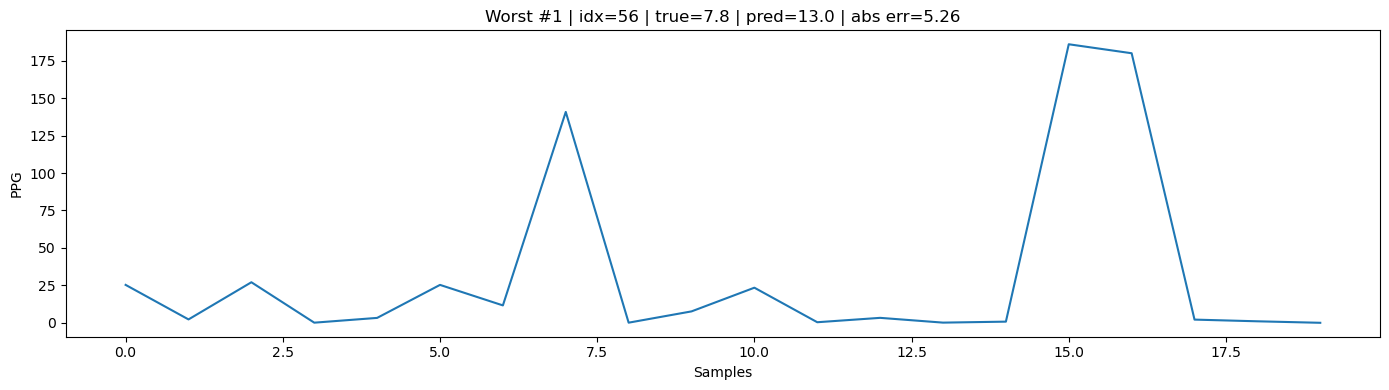

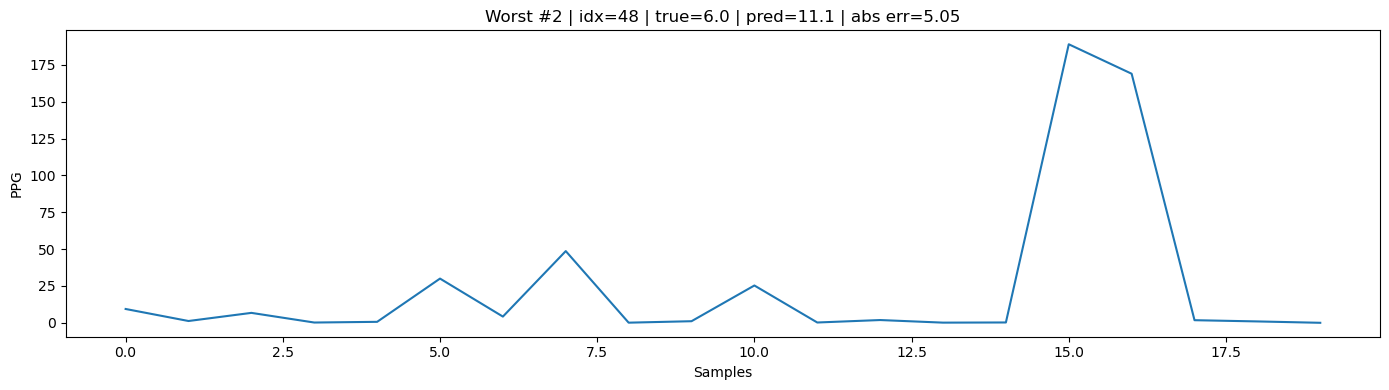

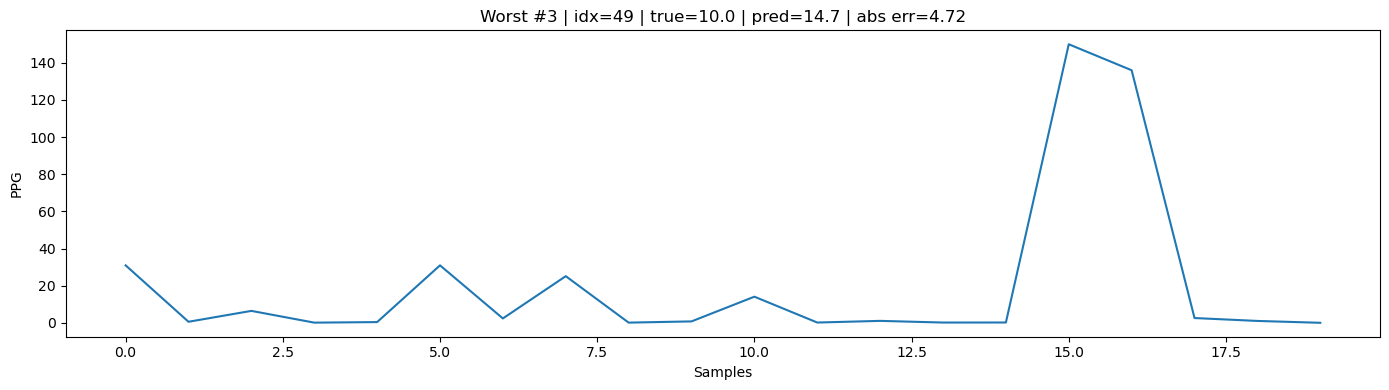

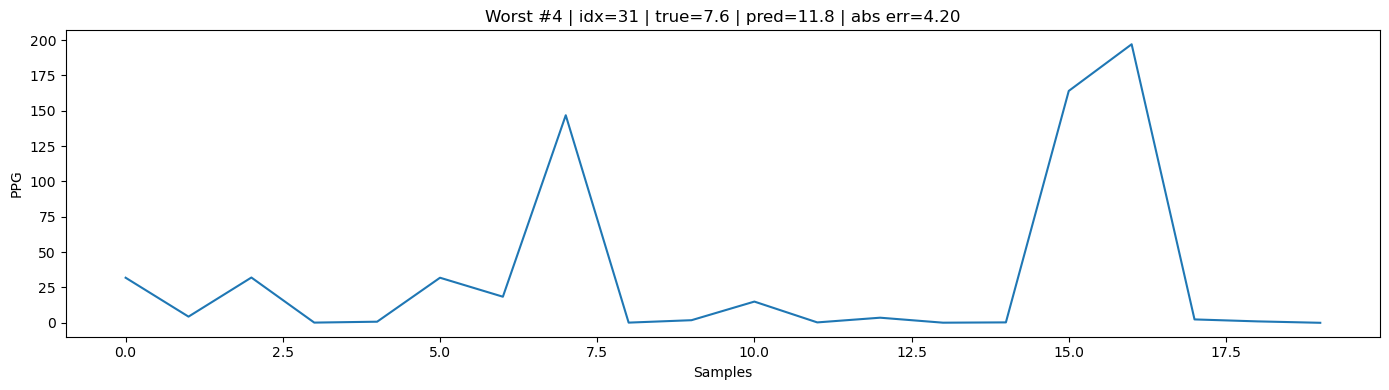

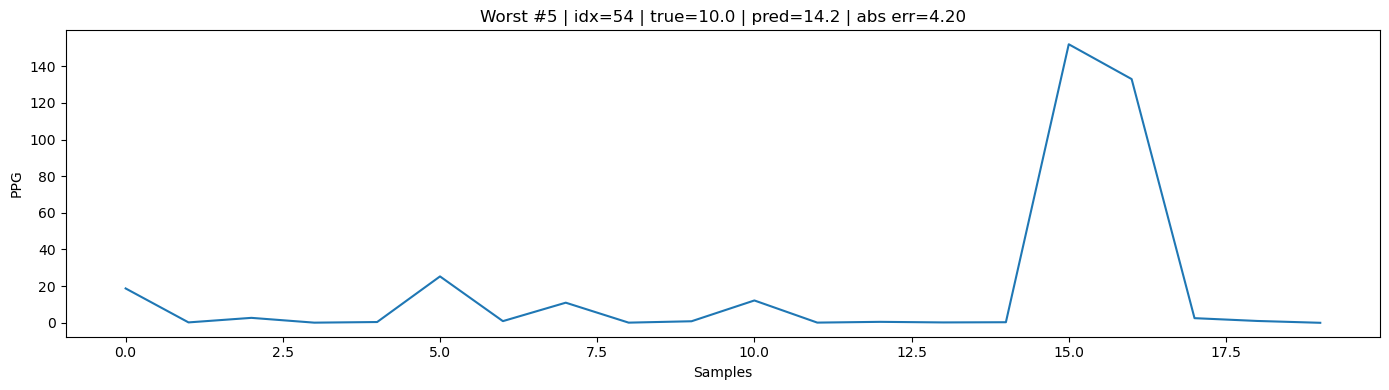

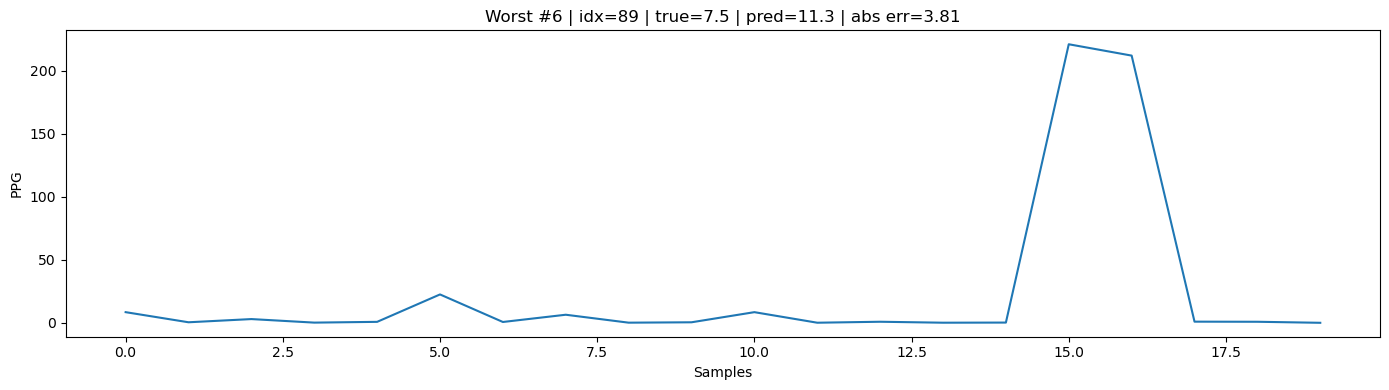

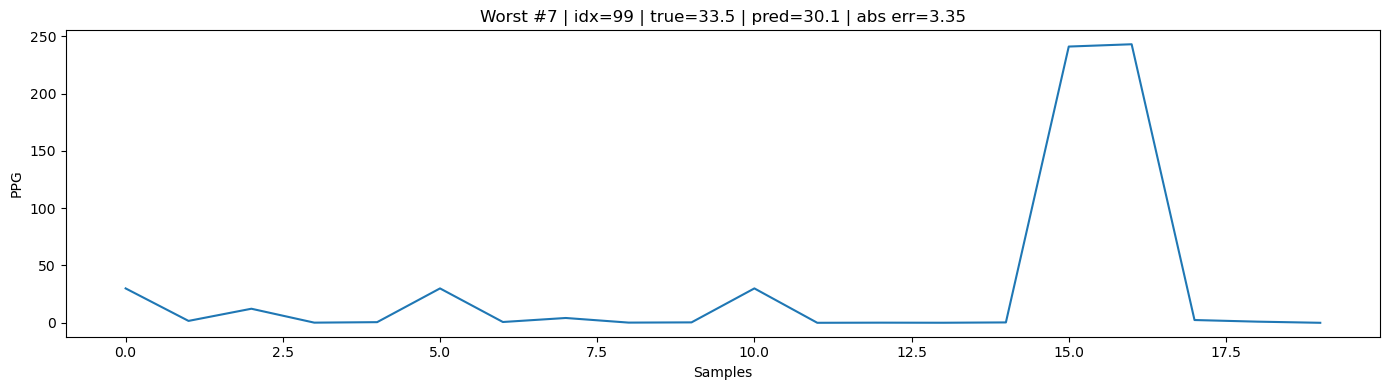

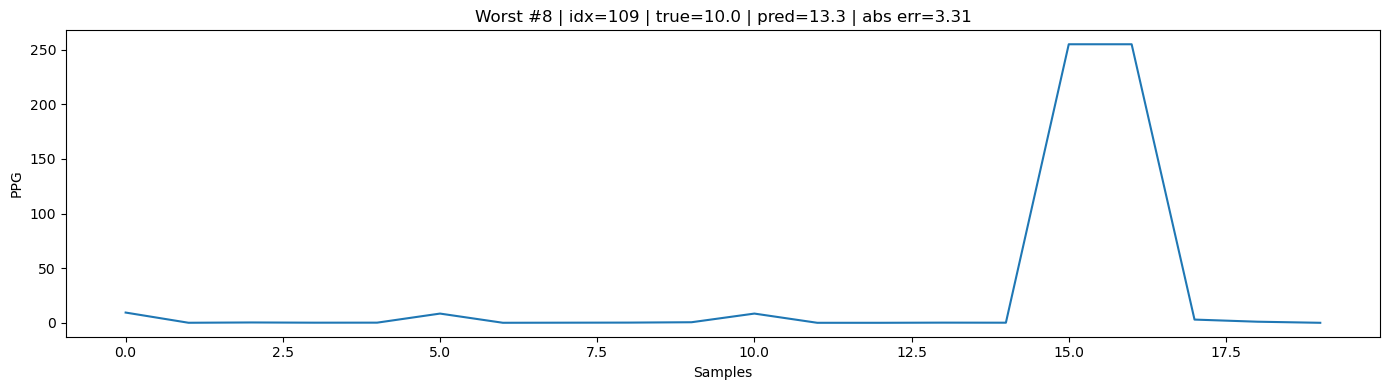

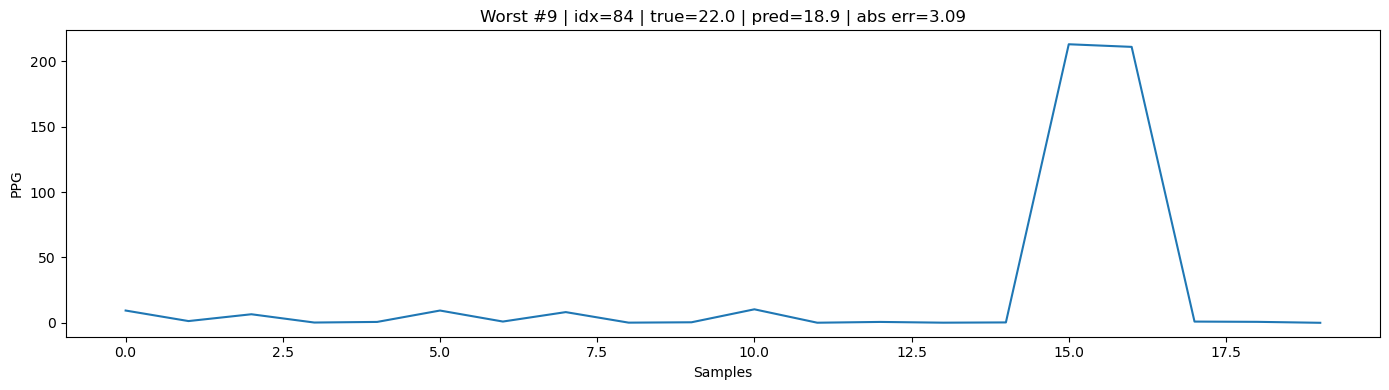

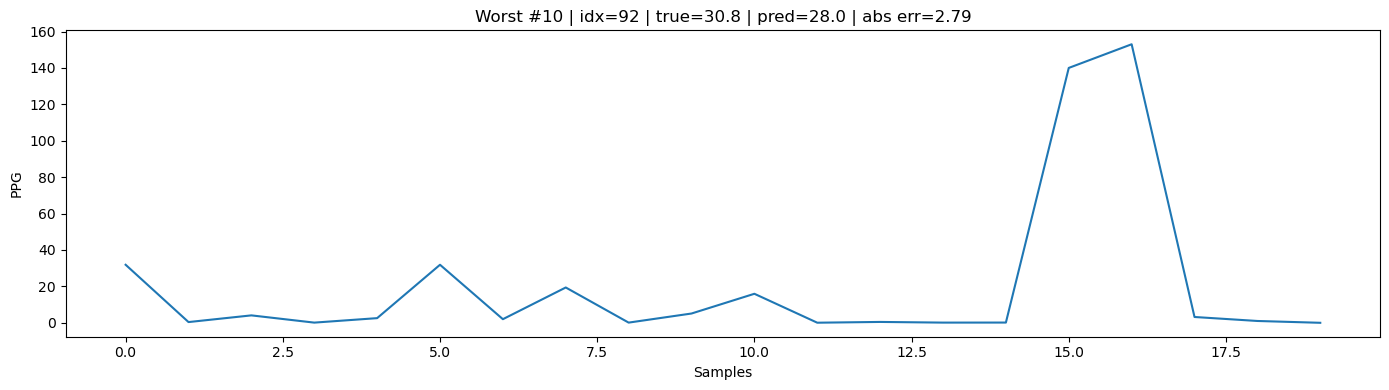

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# RF predicts on validation FEATURES
y_val_pred = rf.predict(X_val)

# Find worst predictions
abs_err = np.abs(y_val - y_val_pred)
worst_idx = np.argsort(abs_err)[-10:][::-1]

print("Worst validation indices:", worst_idx)

# IMPORTANT:
# replace RAW_VAL_WINDOWS with your raw PPG validation windows array
# (same order as X_val / y_val)
for rank, idx in enumerate(worst_idx, 1):
    plt.figure(figsize=(14, 4))
    plt.plot(X_val[idx])
    plt.title(
        f"Worst #{rank} | idx={idx} | true={y_val[idx]:.1f} | "
        f"pred={y_val_pred[idx]:.1f} | abs err={abs_err[idx]:.2f}"
    )
    plt.xlabel("Samples")
    plt.ylabel("PPG")
    plt.tight_layout()
    plt.show()